--- Dataset Loaded Successfully ---
Shape: (4083, 7)

First 5 Rows:
          date      open      high       low     close      volume  \
0  2005-01-03  388.7685  407.0464  388.7685  405.9997  11842921.0   
1  2005-01-04  399.9444  407.3827  395.8329  396.8048  10059943.0   
2  2005-01-05  392.8427  399.1970  385.9277  396.1319  16954266.0   
3  2005-01-06  392.4690  401.0658  390.6747  393.1791  13446517.0   
4  2005-01-07  394.7115  409.2889  394.3751  404.3176  16969845.0   

   dividend_amount  
0              0.0  
1              0.0  
2              0.0  
3              0.0  
4              0.0  

Missing Values:
 date               0
open               0
high               0
low                0
close              0
volume             0
dividend_amount    0
dtype: int64

Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4083 entries, 0 to 4082
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  


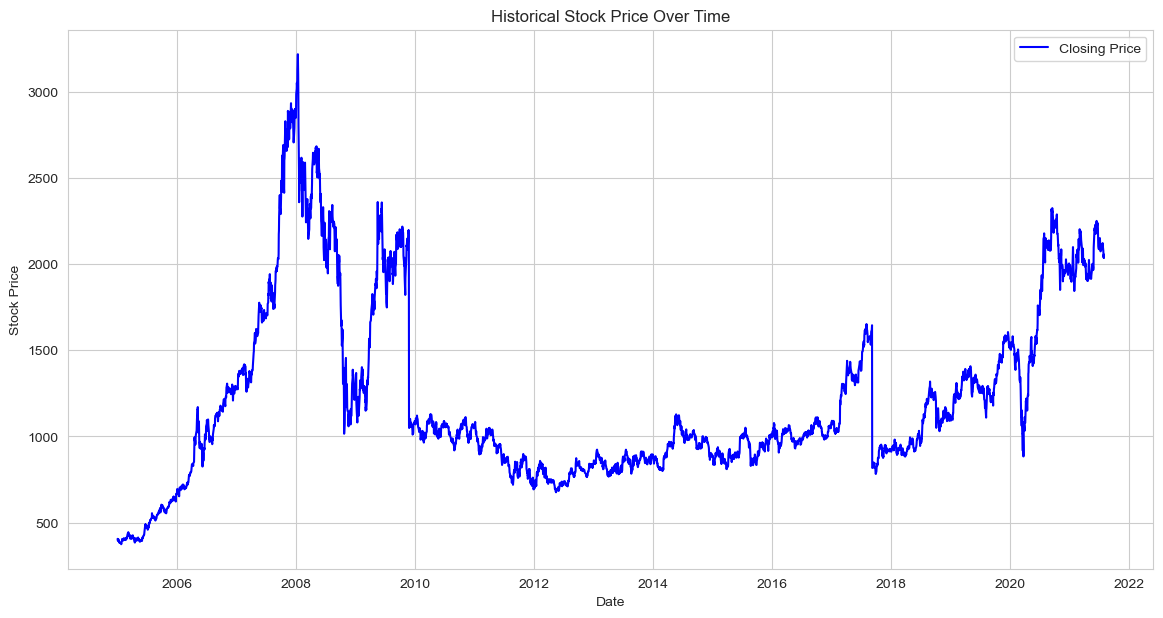

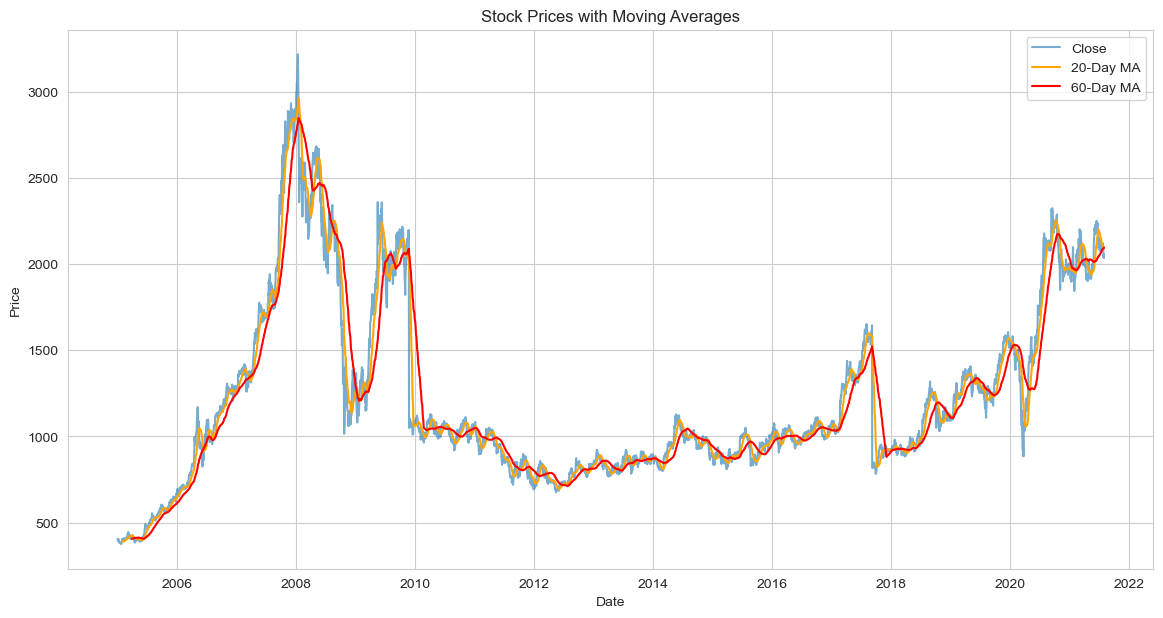


--- Correlation Matrix ---


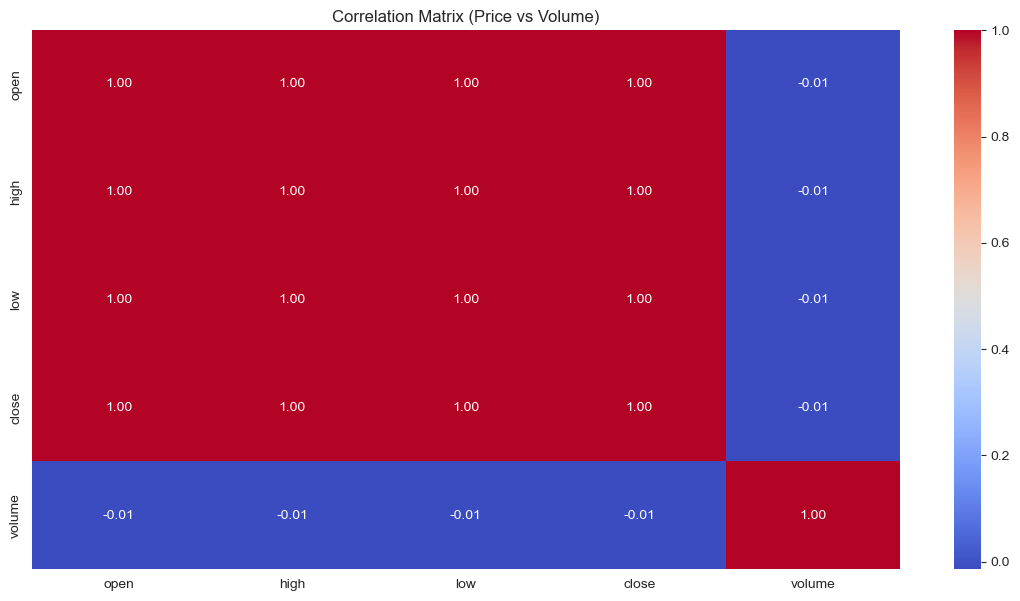


--- Seasonality Analysis ---


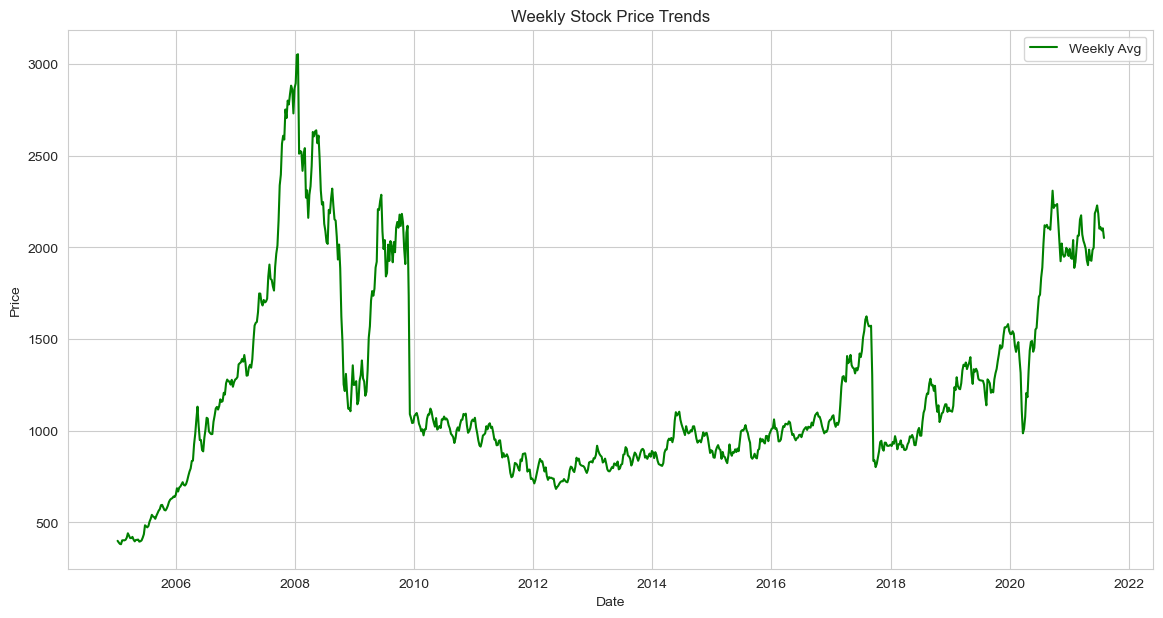

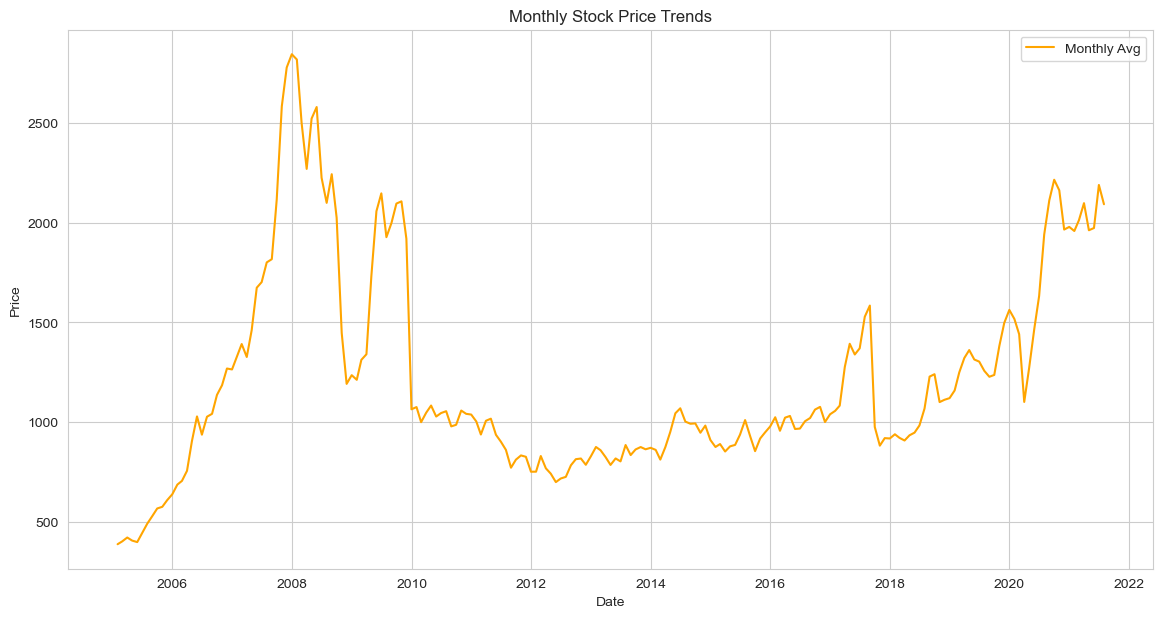

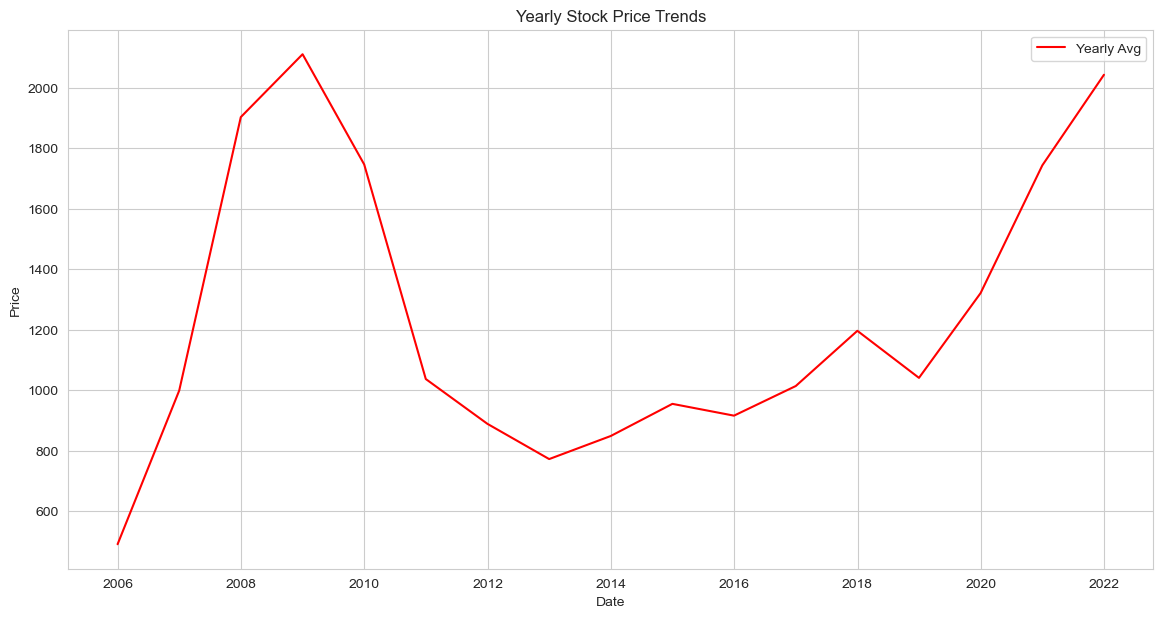


--- Time Series Decomposition ---


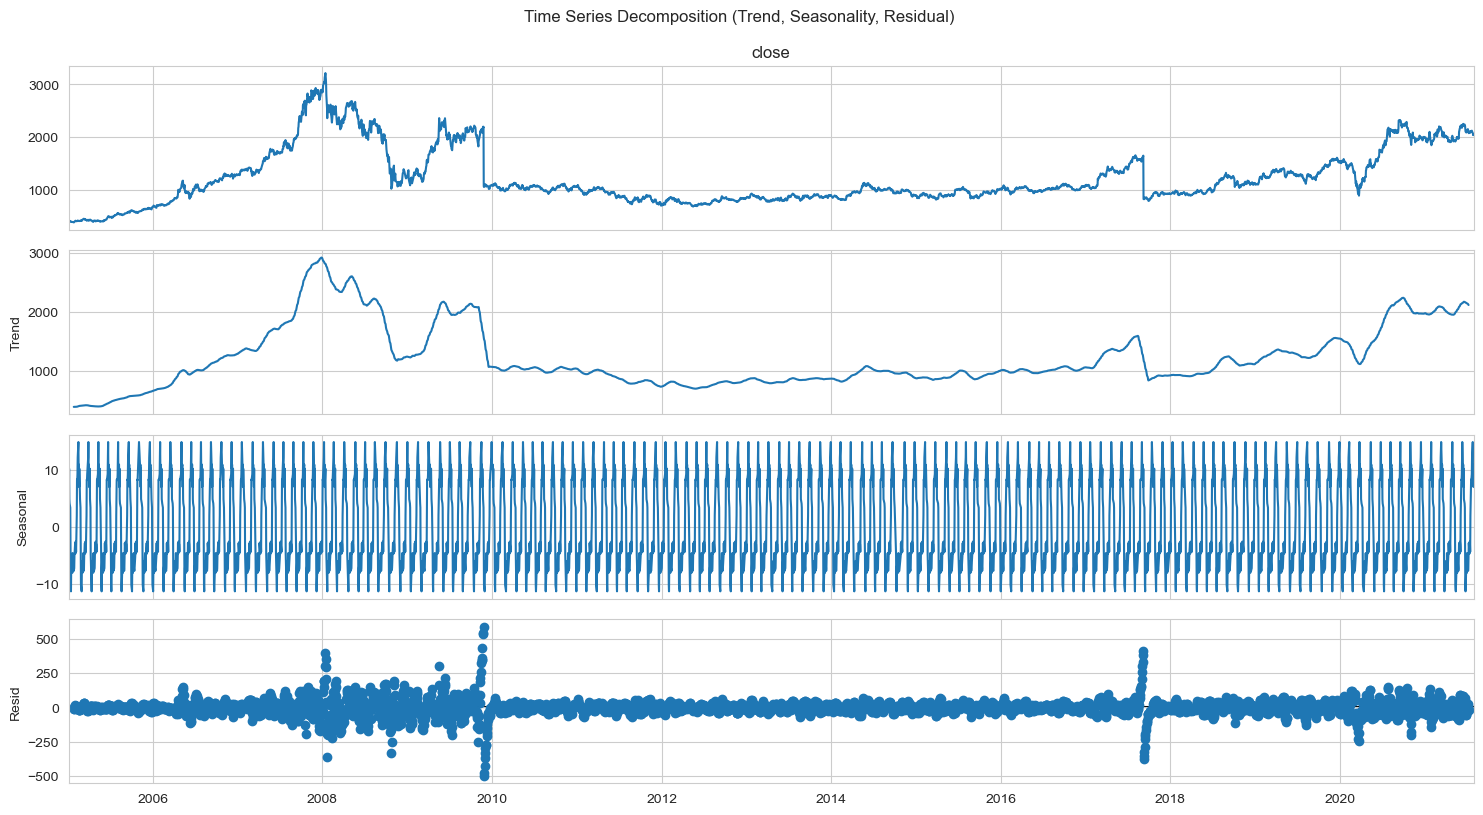


--- ARIMA Forecasting ---
Forecasted Stock Prices for next 30 days:

4083    2034.671083
4084    2034.650528
4085    2034.649948
4086    2034.649932
4087    2034.649931
4088    2034.649931
4089    2034.649931
4090    2034.649931
4091    2034.649931
4092    2034.649931
4093    2034.649931
4094    2034.649931
4095    2034.649931
4096    2034.649931
4097    2034.649931
4098    2034.649931
4099    2034.649931
4100    2034.649931
4101    2034.649931
4102    2034.649931
4103    2034.649931
4104    2034.649931
4105    2034.649931
4106    2034.649931
4107    2034.649931
4108    2034.649931
4109    2034.649931
4110    2034.649931
4111    2034.649931
4112    2034.649931
Name: predicted_mean, dtype: float64


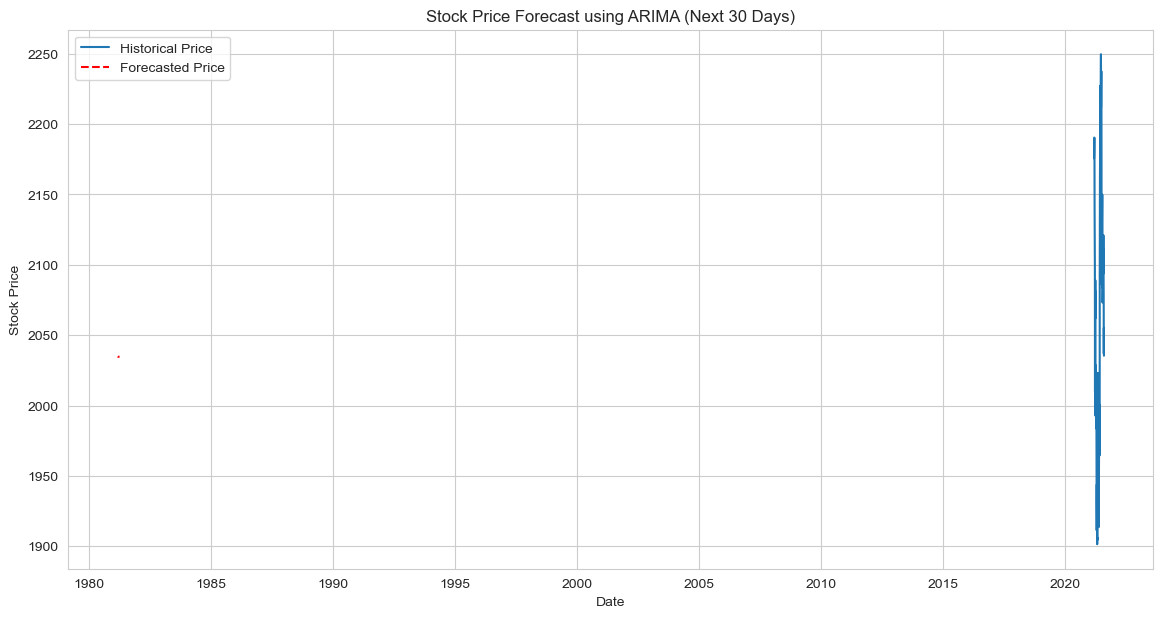


✅ Time Series Stock Market Analysis Completed Successfully!


In [2]:
#%% Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

#%% Step 2: Import Dataset
df = pd.read_csv("stockmarket.csv")
pd.set_option("display.max_columns", None)

print("--- Dataset Loaded Successfully ---")
print("Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n")
df.info()

#%% Step 3: Data Cleaning & Preparation
print("\n--- Converting Date Column ---")
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    df = df.set_index('date')
    print("✅ 'date' column converted to datetime and set as index.")
else:
    raise KeyError("❌ 'date' column not found in dataset!")

# Display first few rows after conversion
print(df.head())

#%% Step 4: Basic Exploration
print("\n--- Basic Statistics ---")
print(df.describe())

#%% Step 5: Plot Historical Stock Price Trends
plt.figure()
plt.plot(df['close'], label='Closing Price', color='blue')
plt.title("Historical Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

#%% Step 6: Moving Averages (Rolling Means)
df['MA_20'] = df['close'].rolling(window=20).mean()
df['MA_60'] = df['close'].rolling(window=60).mean()

plt.figure()
plt.plot(df['close'], label='Close', alpha=0.6)
plt.plot(df['MA_20'], label='20-Day MA', color='orange')
plt.plot(df['MA_60'], label='60-Day MA', color='red')
plt.title("Stock Prices with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

#%% Step 7: Correlation Matrix
print("\n--- Correlation Matrix ---")
numeric_cols = ['open', 'high', 'low', 'close', 'volume']
valid_cols = [col for col in numeric_cols if col in df.columns]
correlation = df[valid_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Price vs Volume)")
plt.show()

#%% Step 8: Seasonality Analysis (Weekly, Monthly, Yearly Trends)
print("\n--- Seasonality Analysis ---")
weekly = df['close'].resample('W').mean()
monthly = df['close'].resample('M').mean()
yearly = df['close'].resample('Y').mean()

plt.figure()
plt.plot(weekly, label='Weekly Avg', color='green')
plt.title("Weekly Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

plt.figure()
plt.plot(monthly, label='Monthly Avg', color='orange')
plt.title("Monthly Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

plt.figure()
plt.plot(yearly, label='Yearly Avg', color='red')
plt.title("Yearly Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

#%% Step 9: Time Series Decomposition
print("\n--- Time Series Decomposition ---")
decomposition = seasonal_decompose(df['close'], model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(15, 8)
plt.suptitle("Time Series Decomposition (Trend, Seasonality, Residual)", y=1.02)
plt.show()

#%% Step 10: ARIMA Forecasting
print("\n--- ARIMA Forecasting ---")
model = ARIMA(df['close'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)
print("Forecasted Stock Prices for next 30 days:\n")
print(forecast)

# Plot Forecast vs Historical
plt.figure()
plt.plot(df['close'].tail(100), label='Historical Price')
plt.plot(forecast, label='Forecasted Price', color='red', linestyle='--')
plt.title("Stock Price Forecast using ARIMA (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

print("\n✅ Time Series Stock Market Analysis Completed Successfully!")

#%% --- Notes for Report/Documentation ---
# 1. Converted date to datetime and used as index for time series analysis.
# 2. Visualized close price trends and moving averages (20-day & 60-day).
# 3. Conducted correlation analysis between stock features.
# 4. Identified seasonality patterns (weekly, monthly, yearly).
# 5. Decomposed time series into trend, seasonality, and residual components.
# 6. Forecasted next 30 days’ prices using ARIMA (1,1,1) model.
# 7. These insights can help identify price patterns, trading opportunities, and market trends.
